In [53]:
import pandas as pd
import numpy as np
import joblib
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Sentence Transformers để tạo embeddings
from sentence_transformers import SentenceTransformer

# Scikit-learn cho mô hình và đánh giá
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [96]:

df = pd.read_csv('data/email_spam.csv', nrows=9000)
df.head()


,title,text,type
0,?? the secrets to SUCCESS,"Hi James,\n\nHave you claim your complimentary...",spam
1,?? You Earned 500 GCLoot Points,"\nalt_text\nCongratulations, you just earned\n...",not spam
2,?? Your GitHub launch code,"Here's your GitHub launch code, @Mortyj420!\n ...",not spam
3,[The Virtual Reward Center] Re: ** Clarifications,"Hello,\n \nThank you for contacting the Virtua...",not spam
4,"10-1 MLB Expert Inside, Plus Everything You Ne...","Hey Prachanda Rawal,\n\nToday's newsletter is ...",spam


In [97]:
# lây embeddings từ file đã lưu
embeddings = joblib.load('data/email_spam.pkl')
# Gán X (features) và y (target)
df['label'] = df['type'].map({'spam': 1, 'not spam': 0})
X = embeddings
y = df['label'].values

In [98]:
print("Kích thước của X:", X.shape)
print("Kích thước của y:", y.shape)

Kích thước của X: (84, 384)
Kích thước của y: (84,)


In [99]:

# (Giữ nguyên code từ trước)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)


In [100]:
# Class Feed Forward Neural Network với Residual Connection
class FeedForwardSpamClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim1: int, hidden_dim2: int, output_dim: int):
        super(FeedForwardSpamClassifier, self).__init__()
        
        # Do đó, `hidden_dim1` phải bằng `input_dim`.
        if input_dim != hidden_dim1:
            raise ValueError(f"Để sử dụng Residual Connection, input_dim ({input_dim}) "
                             f"phải bằng hidden_dim1 ({hidden_dim1}).")

        # Khối Feed-Forward đầu tiên, nơi chúng ta sẽ áp dụng residual connection
        self.feed_forward_block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.Mish(),
            nn.Linear(hidden_dim1, hidden_dim1),
        )
        
        # Khối MLP 
        self.second_block = nn.Sequential(
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.Mish(),
            nn.Linear(hidden_dim2, hidden_dim2),
        )

        # Lớp output để ra quyết định
        self.output_layer = nn.Linear(hidden_dim2, output_dim)
        
        # Lớp chuẩn hóa (Layer Normalization) có thể giúp ổn định việc training với residual connections
        self.layer_norm = nn.LayerNorm(hidden_dim1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Lưu lại giá trị đầu vào ban đầu cho residual connection
        residual = x 
        
        # Dữ liệu đi qua khối feed-forward đầu tiên
        out = self.feed_forward_block(x)
        out = out + residual
        out = self.layer_norm(out) # Áp dụng LayerNorm để ổn định
        
        # Tiếp tục đi qua khối thứ hai
        out = self.second_block(out)
        
        # Lớp đầu ra
        out = self.output_layer(out)
        return out

In [101]:
# --- THAY ĐỔI KHI KHỞI TẠO MODEL ---
INPUT_DIM = X.shape[1]
HIDDEN_DIM_1 = INPUT_DIM
HIDDEN_DIM_2 = 128
OUTPUT_DIM = 1


In [102]:
# Tải lại mô hình để kiểm tra
loaded_model = FeedForwardSpamClassifier(
    input_dim=INPUT_DIM, 
    hidden_dim1=HIDDEN_DIM_1, 
    hidden_dim2=HIDDEN_DIM_2,
    output_dim=OUTPUT_DIM
)
MODEL_PATH = 'checkpoints/ff_spam_classifier_model_mail_data.pth' 
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

FeedForwardSpamClassifier(
  (feed_forward_block): Sequential(
    (0): Linear(in_features=384, out_features=384, bias=True)
    (1): Mish()
    (2): Linear(in_features=384, out_features=384, bias=True)
  )
  (second_block): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): Mish()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
  (layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)

In [103]:
print("\nĐánh giá mô hình trên tập test...")
loaded_model.eval()
with torch.no_grad():
    y_predicted_logits = loaded_model(X)
    y_predicted_prob = torch.sigmoid(y_predicted_logits)
    y_predicted_labels = (y_predicted_prob > 0.5).int()

y_predicted_labels = y_predicted_labels.cpu().numpy()


Đánh giá mô hình trên tập test...



Accuracy: 0.5238

Classification Report:
              precision    recall  f1-score   support

         Ham       0.65      0.67      0.66        58
        Spam       0.21      0.19      0.20        26

    accuracy                           0.52        84
   macro avg       0.43      0.43      0.43        84
weighted avg       0.51      0.52      0.52        84



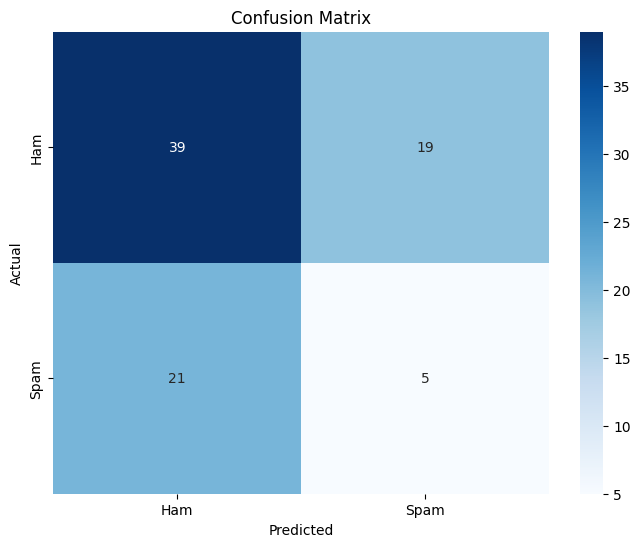

In [104]:
print(f"\nAccuracy: {accuracy_score(y, y_predicted_labels):.4f}")
print("\nClassification Report:")
print(classification_report(y, y_predicted_labels, target_names=['Ham', 'Spam']))

cm = confusion_matrix(y, y_predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()